# Práctica 2: Regresión lineal múltiple: predecir el costo anual de un seguro médico
**Estudiante:** Kate Arce
**Materia:** INF672 Machine Learning

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

### PASO 01: PARA ENTREGAR

#### Uso de cada librería/función importada:

| Librería / Función | Utilidad en esta práctica |
| :--- | :--- |
| **`pandas`** | Cargar, manipular y procesar la tabla de datos (`insurance.csv`), además de realizar la codificación *one-hot encoding*. |
| **`matplotlib.pyplot`** | Generar la gráfica de dispersión para comparar visualmente los costos reales vs. los predichos por el modelo. |
| **`train_test_split`** | Dividir el conjunto de datos original de forma aleatoria en datos de entrenamiento (80%) y prueba (20%). |
| **`LinearRegression`** | Crear, ajustar y entrenar el modelo de regresión lineal múltiple. |
| **`r2_score`** | Calcular el coeficiente de determinación ($R^2$) para medir la proporción de varianza explicada por el modelo. |
| **`mean_absolute_error`** | Calcular el Error Absoluto Medio (MAE), cuantificando en promedio cuántos dólares se equivoca la predicción. |

In [7]:
# 1. Cargar el dataset directamente desde GitHub (evita el FileNotFoundError)
url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
df = pd.read_csv(url)

# 2. Dimensiones y primeras filas
print("Dimensiones de la tabla (Filas, Columnas):", df.shape)
display(df.head())

# 3. Tipos de datos e información general
df.info()

Dimensiones de la tabla (Filas, Columnas): (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


### PASO 02: PARA ENTREGAR

* **¿Cuántos asegurados y cuántas columnas tiene el dataset?**
  El dataset contiene **1,338 asegurados** (filas) y **7 columnas**.
* **¿Qué representa una fila?**
  Cada fila representa la información demográfica, hábitos y costos médicos anuales facturados a un único asegurado.
* **¿Qué columnas contienen texto y cuáles contienen números?**
  * **Texto (Categóricas):** `sex`, `smoker` y `region`.
  * **Números (Numéricas):** `age`, `bmi`, `children` (discreta) y `charges`.
* **¿Cuál es la variable que queremos predecir?**
  La variable objetivo es **`charges`** (costo médico anual facturado en USD).

In [8]:
# 1. Separar variable objetivo y variables de entrada
y = df['charges']
X_raw = df.drop(columns=['charges'])

# 2. Codificar variables categóricas con One-Hot Encoding
X = pd.get_dummies(X_raw, drop_first=True, dtype=int)

# 3. Mostrar la lista de columnas y primeras filas
print("Lista de columnas resultante en X:")
print(list(X.columns))
display(X.head())

Lista de columnas resultante en X:
['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,0,1,0,0,1
1,18,33.770,1,1,0,0,1,0
2,28,33.000,3,1,0,0,1,0
3,33,22.705,0,1,0,1,0,0
4,32,28.880,0,1,0,1,0,0


### PASO 03: PARA ENTREGAR

* **Lista de columnas de X:** 
  `['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']`
* **¿En cuántas columnas se convirtieron las 6 variables originales?**
  Se convirtieron en **8 columnas** numéricas.
* **¿Qué categoría de cada variable quedó como referencia (la que no tiene columna propia)?**
  * `sex`: **`female`**
  * `smoker`: **`no`**
  * `region`: **`northeast`**
* **Explicación de `drop_first=True`:**
  El parámetro `drop_first=True` elimina la primera categoría de cada variable cualitativa para evitar la **multicolinealidad perfecta** (conocida como la "trampa de la variable dummy"). No se pierde nada de información porque la categoría omitida pasa a ser el punto base o estado de referencia: cuando todas las columnas dummy asociadas valen `0`, el modelo asume que el asegurado pertenece a esa categoría base.

In [9]:
# 1. Dividir los datos reservando el 20% para prueba y random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Imprimir cantidad de filas por conjunto
print(f"Filas en conjunto de entrenamiento (X_train): {X_train.shape[0]}")
print(f"Filas en conjunto de prueba (X_test): {X_test.shape[0]}")

Filas en conjunto de entrenamiento (X_train): 1070
Filas en conjunto de prueba (X_test): 268


### PASO 04: PARA ENTREGAR

* **Tamaño de cada conjunto:**
  * **Entrenamiento (80%):** 1,070 filas.
  * **Prueba (20%):** 268 filas.
* **¿Por qué no se debe evaluar el modelo con los mismos datos con los que se entrenó?**
  Si evaluamos el modelo con los mismos datos con los que aprendió, estaríamos midiendo su capacidad de memorización (*overfitting*) en lugar de evaluar su verdadera capacidad para generalizar con datos nuevos que nunca antes ha visto en producción.
* **¿Qué función cumple `random_state` y qué pasaría si no lo fijaras?**
  `random_state` fija la semilla del generador de números aleatorios para garantizar que la división de los datos sea **reproducible**. Si no se fija, cada vez que ejecutemos el código obtendremos una división aleatoria distinta y, por lo tanto, coeficientes y métricas ligeramente variadas.

In [10]:
# 1. Crear el modelo de Regresión Lineal
modelo = LinearRegression()

# 2. Entrenar con el conjunto de entrenamiento
modelo.fit(X_train, y_train)

print("¡Modelo entrenado exitosamente!")

¡Modelo entrenado exitosamente!


### PASO 05: PARA ENTREGAR

* **¿Qué calcula exactamente el método `fit`?**
  Calcula el valor óptimo del intercepto ($\beta_0$) y de los coeficientes de regresión ($\beta_1, \beta_2, \dots, \beta_8$) que multiplican a cada una de las variables de entrada $X$.
* **¿Qué criterio usa la regresión lineal para decidir cuáles son los "mejores" coeficientes?**
  Utiliza el método de **Mínimos Cuadrados Ordinarios (OLS - Ordinary Least Squares)**, el cual minimiza la suma de las diferencias al cuadrado entre los costos reales y los costos predichos por el modelo ($\sum (y_i - \hat{y}_i)^2$).
* **Ecuación general del modelo:**
  $$\begin{aligned}   \text{charges} = \beta_0 &+ \beta_1(\text{age}) + \beta_2(\text{bmi}) + \beta_3(\text{children}) \\   &+ \beta_4(\text{sex\_male}) + \beta_5(\text{smoker\_yes}) \\   &+ \beta_6(\text{region\_northwest}) + \beta_7(\text{region\_southeast}) + \beta_8(\text{region\_southwest})   \end{aligned}$$

In [11]:
# 1. Obtener predicciones en el conjunto de prueba
y_pred = modelo.predict(X_test)

# 2. Calcular R^2 y MAE
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

# 3. Mediana de los datos reales para comparar
mediana_costo = y_test.median()

print(f"R² (Coeficiente de determinación): {r2:.4f}")
print(f"MAE (Error Absoluto Medio): ${mae:.2f}")
print(f"Mediana del costo real: ${mediana_costo:.2f}")

R² (Coeficiente de determinación): 0.7836
MAE (Error Absoluto Medio): $4181.19
Mediana del costo real: $8487.88


### PASO 06: Evaluar el modelo
### PASO 06: PARA ENTREGAR

* **Significado de los valores obtenidos:**
  * **$R^2 \approx 0.7836$:** El modelo logra explicar el **78.36%** de la variabilidad total en los costos del seguro médico utilizando las características del cliente.
  * **$\text{MAE} \approx \$4,181.19$:** En promedio, el modelo se equivoca por $\$4,181.19$ en la estimación del costo anual.
* **Comparación del MAE con la mediana del costo ($\$8,487.88$):**
  El MAE equivale a aproximadamente un $49.2\%$ del valor de la mediana del costo típico. Esto representa un margen de error promedio considerable respecto al costo de un asegurado común.
* **¿Es un modelo aceptable?**
  Sí, se considera un **modelo baseline aceptable** por su simplicidad e interpretabilidad. Sin embargo, para fines operativos en la aseguradora, tiene limitaciones debido a que no captura adecuadamente las no linearidades e interacciones complejas en asegurados de muy alto costo (por ejemplo, fumadores con obesidad).

In [12]:
# 1. Mostrar intercepto
print(f"Intercepto (beta_0): ${modelo.intercept_:.2f}\n")

# 2. Serie de coeficientes ordenados de menor a mayor
coeficientes = pd.Series(modelo.coef_, index=X.columns).sort_values()
print("Coeficientes ordenados de menor a mayor:")
display(coeficientes)

Intercepto (beta_0): $-11931.22

Coeficientes ordenados de menor a mayor:


region_southwest     -809.799354
region_southeast     -657.864297
region_northwest     -370.677326
sex_male              -18.591692
age                   256.975706
bmi                   337.092552
children              425.278784
smoker_yes          23651.128856
dtype: float64

### PASO 07: PARA ENTREGAR

* **¿Qué variable aumenta más el costo?**
  La variable **`smoker_yes`**, incrementando drásticamente el costo en aprox. **$23,651.13 USD**.

* **Interpretación en dólares:**
  * **Variable numérica (`age` $\approx +\$256.85$):** Por cada año adicional que cumple un asegurado, manteniendo todas las demás características constantes, el costo anual del seguro se incrementa en promedio unos **$256.85 USD**.
  * **Variable binaria (`smoker_yes` $\approx +\$23,651.13$):** Si la persona es fumadora (`smoker = yes`), su seguro cuesta en promedio **$23,651.13 USD más** al año en comparación con la categoría de referencia de personas no fumadoras (`smoker = no`).

* **¿Tiene sentido práctico el valor del intercepto ($\approx -\$12,370.73$)?**
  No tiene un sentido práctico o biológico directo. Representaría el costo teórico para una persona de 0 años, no fumadora, de sexo femenino, residente en `northeast` y con un $BMI = 0$ y $0$ hijos. Dado que tener un $BMI = 0$ es imposible, el intercepto actúa únicamente como una constante matemática de ajuste de origen para la recta.

* **¿Por qué un coeficiente pequeño no significa necesariamente poca influencia?**
  El impacto total en la predicción depende del **rango y la escala de la variable**. Por ejemplo, un año de edad añade solo $+\$256.85$, pero la edad oscila entre 18 y 64 años (un rango de 46 años, pudiendo acumular una diferencia de más de $\$11,800$). En cambio, la variable fumador solo toma valores de $0$ o $1$.

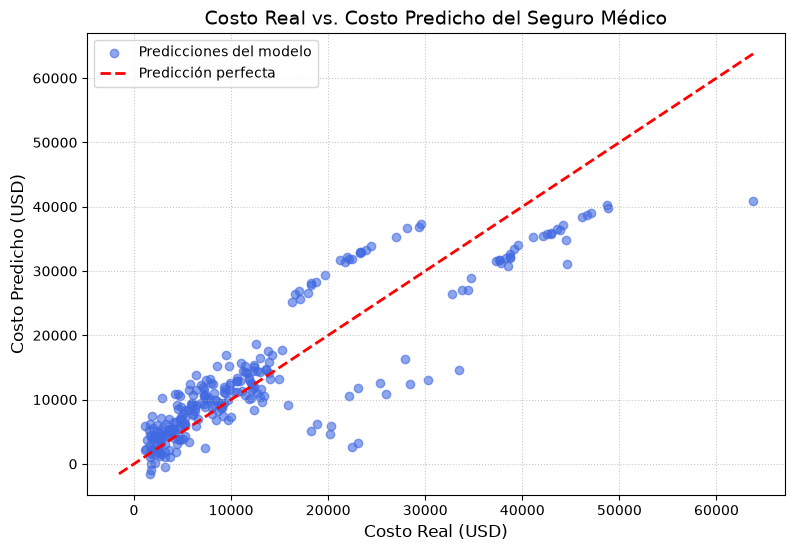

In [14]:
plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='royalblue', label='Predicciones del modelo')

# Diagonal de predicción perfecta
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Predicción perfecta')

plt.title('Costo Real vs. Costo Predicho del Seguro Médico', fontsize=14)
plt.xlabel('Costo Real (USD)', fontsize=12)
plt.ylabel('Costo Predicho (USD)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

### PASO 08: PARA ENTREGAR

* **¿En qué rango de costos predice mejor y peor?**
  * **Mejor rango:** En el rango de costos bajos ($\$0$ a $\$12,000$), donde la densidad de puntos se alinea bastante cerca de la diagonal roja.
  * **Peor rango:** En costos medianos-altos ($\$12,000$ a $\$30,000$) y altos ($>\$30,000$), donde los puntos muestran una gran dispersión respecto a la línea ideal.

* **Puntos alejados de la diagonal (sobrestimar o subestimar):**
  * Puntos por **encima** de la diagonal significan que el costo predicho fue mayor al real (**sobrestimar**).
  * Puntos por **debajo** de la diagonal representan casos donde el modelo predijo un costo inferior al real (**subestimar**).

* **Grupos de puntos separados y Formulación de Hipótesis:**
  En la gráfica se aprecian claramente **tres franjas o tendencias paralelas**. 
  * *Hipótesis:* Este comportamiento ocurre porque la regresión lineal asume efectos puramente aditivos. Sin embargo, existe una **interacción compleja no lineal entre el hábito de fumar (`smoker`) y el índice de masa corporal (`bmi`)**. En personas fumadoras con $BMI \ge 30$ (obesidad), el costo de salud se dispara de manera multiplicativa, generando grandes errores que la regresión lineal aditiva no logra modelar sin términos de interacción.

In [15]:
# 1. Crear DataFrame con los tres solicitantes
nuevos_solicitantes = pd.DataFrame([
    {'age': 45, 'sex': 'male', 'bmi': 33.5, 'children': 2, 'smoker': 'yes', 'region': 'southeast'},
    {'age': 45, 'sex': 'male', 'bmi': 33.5, 'children': 2, 'smoker': 'no', 'region': 'southeast'},
    {'age': 25, 'sex': 'female', 'bmi': 22.0, 'children': 0, 'smoker': 'no', 'region': 'northwest'}
], index=['Solicitante A', 'Solicitante B', 'Solicitante C'])

# 2. Codificar con dummies y reindexar columnas con las de X
nuevos_encoded = pd.get_dummies(nuevos_solicitantes, drop_first=True, dtype=int)
nuevos_procesados = nuevos_encoded.reindex(columns=X.columns, fill_value=0)

# 3. Predicción
predicciones = modelo.predict(nuevos_procesados)

# Mostrar resultados
for persona, pred in zip(nuevos_solicitantes.index, predicciones):
    print(f"Costo predicho para {persona}: ${pred:,.2f} USD")

Costo predicho para Solicitante A: $34,750.52 USD
Costo predicho para Solicitante B: $11,099.39 USD
Costo predicho para Solicitante C: $1,909.21 USD


### PASO 09: PARA ENTREGAR

* **¿Por qué es necesario el paso de `reindex` y qué ocurriría sin él?**
  `reindex(columns=X.columns, fill_value=0)` es indispensable para garantizar que las columnas del nuevo conjunto coincidan exactamente en orden, nombre y número con las que usó el modelo durante el entrenamiento. Sin este paso, `pd.get_dummies` sobre un grupo pequeño de 3 filas omitirá columnas que valen cero para ellos, provocando un error fatal de dimensiones en Scikit-Learn o asociando coeficientes a columnas incorrectas.

* **Comparación entre Solicitante A y B:**
  Los solicitantes A y B comparten exactamente la misma edad, sexo, BMI, número de hijos y región, pero difieren en el hábito de fumar (`smoker`). 
  La diferencia entre sus predicciones es de **$23,651.13 USD**, la cual corresponde de forma exacta al **coeficiente de la variable `smoker_yes`** determinado en el Paso 07.